In [336]:
import os
import numpy as np
import pandas as pd
from obspy import read
from obspy.core.trace import Trace
import matplotlib.pyplot as plt

In [337]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)
t0_mat = (
    df_long.pivot_table(
        index="event",
        columns="band",
        values="t0_dt_mean_dt",
        aggfunc="first"
    )
    .reindex(columns=BANDS)
    .sort_index()
)

print(t0_mat.head())
# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


band                                                               3.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.803000+00:00   
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:28:58.621000+00:00   
1972-01-02 22:20:40.002000+00:00__S15                              NaT   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:40.242000+00:00   
1972-12-06 22:59:00.008000+00:00__S14 1972-12-06 23:12:35.496000+00:00   

band                                                               4.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.620000+00:00   
1971-05-20 17:16:10.013000+00:00__S14                              NaT   
1972-01-02 22:20:40.002000+00:00__S15 1972-01-02 22:33:18.748000+00:00   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:45.132000+00:00   
1972-12-06 22:59:00.008000+00:00__S14

In [ ]:
def select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    *,
    target_deg,
    tol_deg=2.0,
    mode="closest",
    event_col="event",
    dist_col=None
):
    d = out_df.copy()

    if dist_col is None:
        if "epi_deg" in d.columns:
            dist_col = "epi_deg"
        elif "distance_deg" in d.columns:
            dist_col = "distance_deg"
        else:
            raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

    d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
    d = d[d[dist_col].notna()]
    if d.empty:
        return None, None, None

    win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
    if win.empty:
        return None, None, None

    if mode == "closest":
        idx = (win[dist_col] - target_deg).abs().idxmin()
    elif mode == "min":
        idx = win[dist_col].idxmin()
    elif mode == "max":
        idx = win[dist_col].idxmax()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if event_col not in win.columns:
        raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

    chosen_row = win.loc[idx]
    chosen_event = chosen_row[event_col]
    tr = event_to_trace.get(chosen_event)

    return tr, chosen_event, chosen_row


In [ ]:
from scipy.optimize import curve_fit
from obspy import UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window

# ---------------------------
# Signal processing helpers
# ---------------------------
def band_edges(fc, half_bw, fs):
    """Compute lower/upper band edges for a given center frequency."""
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


In [ ]:
# ============================================================
# FULL SCRIPT (single code cell)
# - Select trace/event near target epicentral distance
# - Define diffusion model (stable log + noise floor)
# - Fit per band using (1) log-fit, (2) linear weighted
# - Make ONE figure: 2 columns × N rows (1 row per band)
# - Build a table (DataFrame) with values per band + method
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from obspy import UTCDateTime

# ============================================================
# 0) REQUIRED external helpers you already have in your project
# ============================================================
# You must have these defined somewhere in your codebase:
# - select_trace_and_event_by_epicentral_distance(out_df, event_to_trace, target_deg, tol_deg, mode)
# - band_edges(fc, half_bw, fs) -> (fl, fu)
# - env_and_rms(x, fs, fl, fu, win_s, order) -> (env, rms)
#
# If they are not defined, this script will fail.
# ============================================================


# ============================================================
# 1) Pick trace/event (your function)
# ============================================================
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=100,
    tol_deg=1.0,
    mode="closest"
)

print("Chosen event:", chosen_event)
print("Epi distance:", chosen_row["epi_deg"])


In [ ]:


# ============================================================
# 2) Diffusion envelope: stable linear + stable log amplitude
# ============================================================
def _diffusion_log_e(tt, A, q, a, s, D):
    """
    log(amp_diff^2) without noise floor:
      amp_diff^2 = A^2 * q^(a t) / (a t) * exp( -D^2 / (s^2 a t) )
    """
    tt = np.asarray(tt, float)
    tt = np.maximum(tt, 1e-3)

    q = np.clip(q, 1e-12, 1 - 1e-12)
    a = np.maximum(a, 1e-12)
    s = np.maximum(s, 1e-6)
    A = np.maximum(A, 1e-30)

    return (
        2.0 * np.log(A)
        + (a * tt) * np.log(q)
        - np.log(a * tt)
        - (D**2) / (s**2 * a * tt)
    )

def diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 )"""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)
    return np.sqrt(np.exp(log_e) + n0**2)

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    return 0.5 * np.logaddexp(log_e, log_n0sq)




# ============================================================
# 3) Shared helpers: masks, init/bounds, misfits
# ============================================================
def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0, t_end_safe=10.0):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    pre = t < (t0_mean - 10)
    if not np.any(pre):
        raise RuntimeError("No samples before t0_mean for noise floor estimate.")
    n0 = float(np.mean(amp[pre]))
    n0 = max(n0, 1e-30)

    t_eff = t - t0_mean

    # EXCLUDE last t_end_safe seconds (relative to end of trimmed window)
    t_end = t.max()
    mask = (t_eff > tmin_after_t0) & (t <= (t_end - t_end_safe)) & np.isfinite(amp) & (amp > 0)

    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if t_fit.size < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
    return n0, t_eff, t_fit, amp_fit


def _p0_bounds(amp_fit, D, fit_dt=True): # A, q, a, s, 
    if fit_dt:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2), 0.0)
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3,  -500),
            (1e+03, 1,    10,    1e6,   +500),
        )
    else:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2))
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3),
            (1e+03, 1,    10,    1e6),
        )
    return p0, bounds

def _misfits(amp_obs, amp_pred, sigma=None):
    amp_obs = np.asarray(amp_obs, float)
    amp_pred = np.asarray(amp_pred, float)
    resid = amp_obs - amp_pred

    out = {}
    out["RMS"] = float(np.sqrt(np.mean(resid**2)))
    out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
    out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

    if sigma is not None:
        sigma = np.asarray(sigma, float)
        out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
    return out


# ============================================================
# 4) Fit: (1) log-fit, (2) linear weighted
# ============================================================
def fit_three_ways(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, t_end_safe=10.0, fit_dt=False,
    weight_mode="hybrid",
    maxfev=500000 
):
    """
    Returns dict with keys: 'log', 'linear_weighted'
    Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit (+sigma for weighted)
    """
    n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
    p0, bounds = _p0_bounds(amp_fit, D, fit_dt=fit_dt)

    # ---------- (1) LOG FIT ----------
    y_log = np.log(amp_fit)

    if fit_dt:
        def f_log(tt, A, q, a, s, dt):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s, dt = popt_log
    else:
        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s = popt_log
        dt = 0.0

    amp_pred_log = diffusion_amp_floor(t_fit, A, q, a, s, D, n0, dt)
    mis_log = _misfits(amp_fit, amp_pred_log)

    # ---------- (2) LINEAR WEIGHTED ----------
    if weight_mode == "hybrid":
        sigma = np.sqrt(amp_fit**2 + n0**2)
    elif weight_mode == "relative":
        sigma = np.maximum(amp_fit, n0)
    elif weight_mode == "noise":
        sigma = np.full_like(amp_fit, n0, dtype=float)
    else:
        raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

    if fit_dt:
        def f_lin(tt, A, q, a, s, dt):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, dt)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3, dt3 = popt_w
    else:
        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3 = popt_w
        dt3 = 0.0

    amp_pred_w = diffusion_amp_floor(t_fit, A3, q3, a3, s3, D, n0, dt3)
    mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

    return {
        "log": dict(
            popt=popt_log, pcov=pcov_log, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_log,
            misfit=mis_log
        ),
        "linear_weighted": dict(
            popt=popt_w, pcov=pcov_w, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_w,
            sigma=sigma, misfit=mis_w
        ),
    }


# ============================================================
# 5) Time trimming + setup (PER-BAND t0 references)
# ============================================================

# Per-band Excel t0s for the chosen event
t0_row = t0_mat.loc[chosen_event]  # Series indexed by band

# Choose a single trimming window that contains all band-specific t0's
# (use earliest available t0 across bands)
t0_min_utc = t0_row.dropna().min()
if pd.isna(t0_min_utc):
    raise RuntimeError(f"No t0_dt_mean available for any band for event={chosen_event}")

t0_min_obspy = UTCDateTime(t0_min_utc.to_pydatetime())

start_trim = t0_min_obspy - 300
end_trim   = t0_min_obspy + 2000

# Short trimmed trace (for fitting)
tr_trimmed = tr_chosen.copy()
tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# Long tail trace (for plotting tail)
tr_tail = tr_chosen.copy()
tr_tail.trim(starttime=start_trim)

# Time axis for trimmed window (0 at start_trim)
t = tr_trimmed.times()
t_tail = tr_tail.times()

# Choose smoothing/bands
half_bw = 0.5
win_s   = 10
order   = 4

# IMPORTANT: use the same bands as your Excel bands (or a subset)
frequency_bands = BANDS.copy()

fs_trim = tr_trimmed.stats.sampling_rate
fs_tail = tr_tail.stats.sampling_rate

# Epicentral distance in km (your rule)
D_km = float(chosen_row["epi_deg"]) * 30.0

print("Global start_trim:", tr_trimmed.stats.starttime)
print("Earliest t0 (UTC):", t0_min_utc)
print("D_km:", D_km)
print("Number of bands:", len(frequency_bands))



# ============================================================
# 6) Loop bands: compute RMS, fit, store table rows, and plot 2×N figure
# ============================================================
methods = ["log", "linear_weighted"]
linestyles = {"log": "--", "linear_weighted": "-."}

n_bands = len(frequency_bands)
fig, axes = plt.subplots(
    nrows=n_bands,
    ncols=2,
    figsize=(18, 3.6 * n_bands),
    sharex=True
)

if n_bands == 1:
    axes = np.array([axes])

rows = []

for i, fc_band in enumerate(frequency_bands):
    # --- band-specific Excel t0 ---
    t0_utc_band = t0_row.get(fc_band, pd.NaT)
    if pd.isna(t0_utc_band):
        print(f"Skipping band {fc_band}: no t0 in Excel for event {chosen_event}")
        continue

    t0_obspy_band = UTCDateTime(t0_utc_band.to_pydatetime())
    t0_line_band = float(t0_obspy_band - tr_trimmed.stats.starttime)  # seconds since start_trim

    # --- trimmed RMS ---
    fl, fu = band_edges(fc_band, half_bw, fs_trim)
    env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

    # --- tail RMS ---
    fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
    env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

    # --- fit ---
    res = fit_three_ways(
        t, rms,
        D=D_km,
        t0_mean=t0_line_band,
        tmin_after_t0= -win_s/2,
        fit_dt=True,
        weight_mode="hybrid",
        t_end_safe=10.0
    )

    # --- model axis only after t0 ---
    t_eff_all = t - t0_line_band
    mask_model = t_eff_all > 0
    t_model = t_eff_all[mask_model]
    t_model_abs = t_model + t0_line_band

    # --- axes for this row ---
    ax_log = axes[i, 0]
    ax_lin = axes[i, 1]

    # Observations (label only once for shared legend)
    ax_log.semilogy(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_log.semilogy(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    ax_lin.plot(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_lin.plot(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    # t0 line
    ax_log.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)
    ax_lin.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)

    # Overlay both fitted models + store table rows
    for method in methods:
        popt = np.asarray(res[method]["popt"], float)
        n0 = float(res[method]["n0"])
        mis = res[method]["misfit"]

        if popt.size == 5:
            A, q, a, s, dt = popt
        else:
            A, q, a, s = popt
            dt = 0.0

        amp_model = diffusion_amp_floor(t_model, A, q, a, s, D_km, n0, dt)

        ax_log.semilogy(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )
        ax_lin.plot(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )



        rows.append({
            "fc_center_Hz": float(fc_band),
            "f_low_Hz": float(fc_band - half_bw),
            "f_high_Hz": float(fc_band + half_bw),
            "half_bw_Hz": float(half_bw),
            "win_s": float(win_s),
            "order": int(order),
            "D_km": float(D_km),
            "t0_line_s": float(t0_line_band),
            "t0_utc": pd.Timestamp(t0_utc_band),  # optional but very useful
            "method": method,
            "n0": n0,
            "A": float(A),
            "q": float(q),
            "a_1_per_s": float(a),
            "s_km": float(s),
            "dt_s": float(dt),
            "RMS": float(mis["RMS"]),
            "Relative_RMS": float(mis["Relative_RMS"]),
            "Log_RMS": float(mis["Log_RMS"]),
            "WRMS": float(mis.get("WRMS", np.nan)),
        })

    # Row formatting
    for ax in (ax_log, ax_lin):
        ax.set_xlim(-50, 1000)
        ax.grid(True, which="both", alpha=0.2)

    ax_log.set_ylabel(f"{fc_band:.1f} ± {half_bw:.1f} Hz")

    if i == 0:
        ax_log.set_title("Semilogy")
        ax_lin.set_title("Linear")

    if i == n_bands - 1:
        ax_log.set_xlabel("Time since start_trim (s)")
        ax_lin.set_xlabel("Time since start_trim (s)")

# Global legend (from first row)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 7) Create a formatted table in the figure (no printing)
# ============================================================

df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Round values for readability
df_display = df_bands.copy()
df_display = df_display.round({
    "A": 10,
    "q": 5,
    "a_1_per_s": 5,
    "s_km": 2,
    "dt_s": 3,
    "RMS": 15,
    "Relative_RMS": 15,
    "Log_RMS": 15,
    "WRMS": 15,
})

# Select only the columns you want to show
cols_to_show = [
    "fc_center_Hz",
    "method",
    "A",
    "q",
    "a_1_per_s",
    "s_km",
    "dt_s",
    "RMS",
    "WRMS"
]

df_display = df_display[cols_to_show]

# ---- Create table figure ----
fig_table, ax_table = plt.subplots(figsize=(18, 0.5 * len(df_display)))
ax_table.axis("off")

table = ax_table.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.3)

plt.title("Diffusion Fit Parameters per Frequency Band", pad=20)
plt.tight_layout()
plt.show()
# ============================================================
# 8) Parameter-vs-frequency summary figure (subplots)
# ============================================================

# Ensure df exists
df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Parameters to plot
params = ["n0", "A", "q", "a_1_per_s", "s_km", "dt_s", "RMS", "WRMS"]

# Pivot: index = frequency, columns = method, values = parameter
wide = {}
for p in params:
    wide[p] = df_bands.pivot(index="fc_center_Hz", columns="method", values=p)

# Subplot layout
n = len(params)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, p in zip(axes, params):
    w = wide[p]

    # x = frequencies
    x = w.index.values

    # plot both methods if present
    if "log" in w.columns:
        ax.plot(x, w["log"].values, marker="o", label="log")
    if "linear_weighted" in w.columns:
        ax.plot(x, w["linear_weighted"].values, marker="s", label="linear_weighted")

    ax.set_title(p)
    ax.set_xlabel("fc_center_Hz")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True)

# Hide unused axes
for ax in axes[len(params):]:
    ax.axis("off")

plt.tight_layout()

plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def best_safe_start_by_lsq(
    t, amp, *, D,
    safe_start_grid=np.arange(100.0, 301.0, 10.0),
    trim_s=350.0,
    maxfev=200000,
    plot=True
):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    bounds = (
        (1e-30, 1e-12, 1e-12, 1e-3),
        (1e+03, 1.0,   10.0,  1e6),
    )

    scan_results = []
    best = None

    for ss in safe_start_grid:
        ss = float(ss)

        # -------------------------
        # Noise floor
        # -------------------------
        noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
        if not np.any(noise_mask):
            continue
        n0 = float(np.mean(amp[noise_mask]))
        n0 = max(n0, 1e-30)

        # -------------------------
        # Fit window
        # -------------------------
        fit_start, fit_end = ss, ss + trim_s
        fit_mask = (t >= fit_start) & (t <= fit_end) & np.isfinite(amp) & (amp > 0)
        t_fit = t[fit_mask]
        amp_fit = amp[fit_mask]
        if t_fit.size < 20:
            continue

        # -------------------------
        # Initial guess
        # -------------------------
        A0 = float(np.median(amp_fit))
        q0 = 0.98
        a0 = 5e-3
        s0 = max(D / 4.0, 1e-2)
        p0 = (A0, q0, a0, s0)

        y = np.log(amp_fit)

        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

        try:
            popt, pcov = curve_fit(
                f_log, t_fit, y,
                p0=p0, bounds=bounds, maxfev=maxfev
            )
        except Exception:
            continue

        y_pred = f_log(t_fit, *popt)
        sse = float(np.sum((y - y_pred) ** 2))

        result = {
            "safe_start": ss,
            "SSE": sse,
            "popt": popt,
            "pcov": pcov,
            "n0": n0,
            "fit_start": fit_start,
            "fit_end": fit_end,
        }


        scan_results.append(result)

        if (best is None) or (sse < best["SSE"]):
            best = result

    if best is None:
        raise RuntimeError("No successful fits in scan.")

    # ============================================================
    # PLOTTING
    # ============================================================
    if plot:

        # ---------- Plot 1: SSE vs safe_start ----------
        ss_vals = [r["safe_start"] for r in scan_results]
        sse_vals = [r["SSE"] for r in scan_results]

        plt.figure(figsize=(8,4))
        plt.plot(ss_vals, sse_vals, marker='o')
        plt.axvline(best["safe_start"], color='r', linestyle='--',
                    label=f"Best = {best['safe_start']:.1f}s")
        plt.xlabel("safe_start (s)")
        plt.ylabel("Log-space SSE")
        plt.title("LSQ vs safe_start")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ---------- Plot 2: Best fit on trace ----------
        A, q, a, s = best["popt"]
        n0 = best["n0"]

        t_model = np.linspace(best["fit_start"], best["fit_end"], 1000)
        amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, n0)

        fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

        # Linear
        axes[0].plot(t, amp, color="k", lw=1, label="Observed")
        axes[0].plot(t_model, amp_model, lw=2, label="Best Fit")
        axes[0].axvline(best["fit_start"], ls="--", color="0.3")
        axes[0].axvline(best["fit_end"], ls="--", color="0.3")
        axes[0].set_title("Linear")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # Semilogy
        axes[1].semilogy(t, amp, color="k", lw=1, label="Observed")
        axes[1].semilogy(t_model, amp_model, lw=2, label="Best Fit")
        axes[1].axvline(best["fit_start"], ls="--", color="0.3")
        axes[1].axvline(best["fit_end"], ls="--", color="0.3")
        axes[1].set_title("Semilogy")
        axes[1].set_xlabel("Time (s)")
        axes[1].grid(True, which="both", alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return best
best = best_safe_start_by_lsq(
    t,
    rms,
    D=D_km,
    safe_start_grid=np.arange(100, 300, 5),
    trim_s=500,
    plot=True
)
A, q, a, s = best["popt"]
n0 = best["n0"]

print("\nBest-fit parameters:")
print(f"A  = {A:.6e}")
print(f"q  = {q:.6f}")
print(f"a  = {a:.6e}")
print(f"s  = {s:.6f}")
print(f"n0 = {n0:.6e}")


print("Best safe_start:", best["safe_start"])
print("Minimum SSE:", best["SSE"])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    return 0.5 * np.logaddexp(log_e, log_n0sq)



def best_safe_start_by_lsq(
    t, amp, *, D,
    t0excel_s,                 # <-- NEW: t0 (seconds on same time axis as t)
    end_after_t0=200.0,        # <-- NEW: fit_end = t0excel_s + end_after_t0
    safe_start_grid=np.arange(100.0, 301.0, 10.0),
    maxfev=200000,
    plot=True
):
    """
    t: time axis in seconds (same as your trace window, e.g. 't' from tr_trimmed.times()).
    t0excel_s: Excel t0 time in seconds on this same axis (e.g. t0_line_band).
    We scan safe_start (ss) values (absolute seconds on same axis),
    estimate n0 from [0, ss), fit in [ss, t0excel_s + end_after_t0].
    """

    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    t0excel_s = float(t0excel_s)
    fit_end_abs = t0excel_s + float(end_after_t0)

    bounds = (
        (1e-30, 1e-12, 1e-12, 1e-3),
        (1e+03, 1.0,   10.0,  1e6),
    )

    scan_results = []
    best = None

    for ss in safe_start_grid:
        ss = float(ss)

        # Require a valid window: ss must be < fit_end_abs
        if ss >= fit_end_abs:
            continue

        # -------------------------
        # Noise floor from beginning of trace to ss
        # -------------------------
        noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
        if not np.any(noise_mask):
            continue
        n0 = float(np.median(amp[noise_mask]))   # median is robust
        n0 = max(n0, 1e-30)

        # -------------------------
        # Fit window: [ss, t0excel + end_after_t0]
        # -------------------------
        fit_start, fit_end = ss, fit_end_abs
        fit_mask = (t >= fit_start) & (t <= fit_end) & np.isfinite(amp) & (amp > 0)
        t_fit = t[fit_mask]
        amp_fit = amp[fit_mask]
        if t_fit.size < 20:
            continue

        # -------------------------
        # Initial guess
        # -------------------------
        A0 = float(np.median(amp_fit))
        q0 = 0.98
        a0 = 5e-3
        s0 = max(D / 4.0, 1e-2)
        p0 = (A0, q0, a0, s0)

        y = np.log(amp_fit)

        def f_log(tt, A, q, a, s):
            # expects tt in "seconds since t0" in your model; here we are feeding absolute t.
            # If your model expects absolute t (as in your current code), keep as-is.
            # If your model expects time since t0excel, pass (tt - t0excel_s) instead.
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

        try:
            popt, pcov = curve_fit(
                f_log, t_fit, y,
                p0=p0, bounds=bounds, maxfev=maxfev
            )
        except Exception:
            continue

        y_pred = f_log(t_fit, *popt)
        sse = float(np.sum((y - y_pred) ** 2))

        result = {
            "safe_start": ss,
            "SSE": sse,
            "popt": popt,
            "pcov": pcov,
            "n0": n0,
            "fit_start": fit_start,
            "fit_end": fit_end,
            "t0excel_s": t0excel_s,
            "end_after_t0": float(end_after_t0),
        }

        scan_results.append(result)

        if (best is None) or (sse < best["SSE"]):
            best = result

    if best is None:
        raise RuntimeError("No successful fits in scan. Try widening the window or grid.")

    # ============================================================
    # PLOTTING
    # ============================================================
    if plot:
        # ---------- Plot 1: SSE vs safe_start ----------
        ss_vals = [r["safe_start"] for r in scan_results]
        sse_vals = [r["SSE"] for r in scan_results]

        plt.figure(figsize=(8, 4))
        plt.plot(ss_vals, sse_vals, marker="o")
        plt.axvline(best["safe_start"], color="r", linestyle="--",
                    label=f"Best = {best['safe_start']:.1f}s")
        plt.axvline(t0excel_s, color="0.4", linestyle=":", label="t0excel")
        plt.xlabel("safe_start (s)")
        plt.ylabel("Log-space SSE")
        plt.title("LSQ vs safe_start (fit_end = t0excel + end_after_t0)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ---------- Plot 2: Best fit on trace ----------
        A, q, a, s = best["popt"]
        n0 = best["n0"]

        t_model = np.linspace(best["fit_start"], best["fit_end"], 1000)
        amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, n0)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        # Linear
        axes[0].plot(t, amp, color="k", lw=1, label="Observed")
        axes[0].plot(t_model, amp_model, lw=2, label="Best Fit")
        axes[0].axvline(best["fit_start"], ls="--", color="0.3", label="fit_start")
        axes[0].axvline(best["fit_end"], ls="--", color="0.3", label="fit_end")
        axes[0].axvline(t0excel_s, ls=":", color="0.4", label="t0excel")
        axes[0].set_title("Linear")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # Semilogy
        axes[1].semilogy(t, amp, color="k", lw=1, label="Observed")
        axes[1].semilogy(t_model, amp_model, lw=2, label="Best Fit")
        axes[1].axvline(best["fit_start"], ls="--", color="0.3", label="fit_start")
        axes[1].axvline(best["fit_end"], ls="--", color="0.3", label="fit_end")
        axes[1].axvline(t0excel_s, ls=":", color="0.4", label="t0excel")
        axes[1].set_title("Semilogy")
        axes[1].set_xlabel("Time (s)")
        axes[1].grid(True, which="both", alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return best


# -------------------------
# -------------------------
after_t0 = 300
best = best_safe_start_by_lsq(
    t,
    rms,
    D=D_km,
    t0excel_s=t0_line_band,          # <-- your Excel t0 line in seconds on this axis
    end_after_t0=after_t0,              # <-- fit ends at t0 + 250 s
    safe_start_grid=np.arange(10, after_t0, 5),
    plot=True
)

A, q, a, s = best["popt"]
n0 = best["n0"]

print("\nBest-fit parameters:")
print(f"A  = {A:.6e}")
print(f"q  = {q:.6f}")
print(f"a  = {a:.6e}")
print(f"s  = {s:.6f}")
print(f"n0 = {n0:.6e}")
print("Best safe_start:", best["safe_start"])
print("Minimum SSE:", best["SSE"])
print("Fit window:", best["fit_start"], "to", best["fit_end"])
print("t0excel_s:", best["t0excel_s"], "end_after_t0:", best["end_after_t0"])


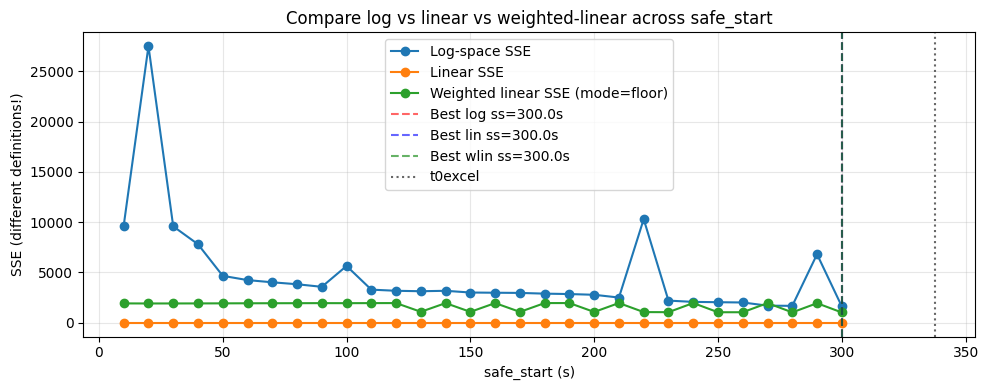

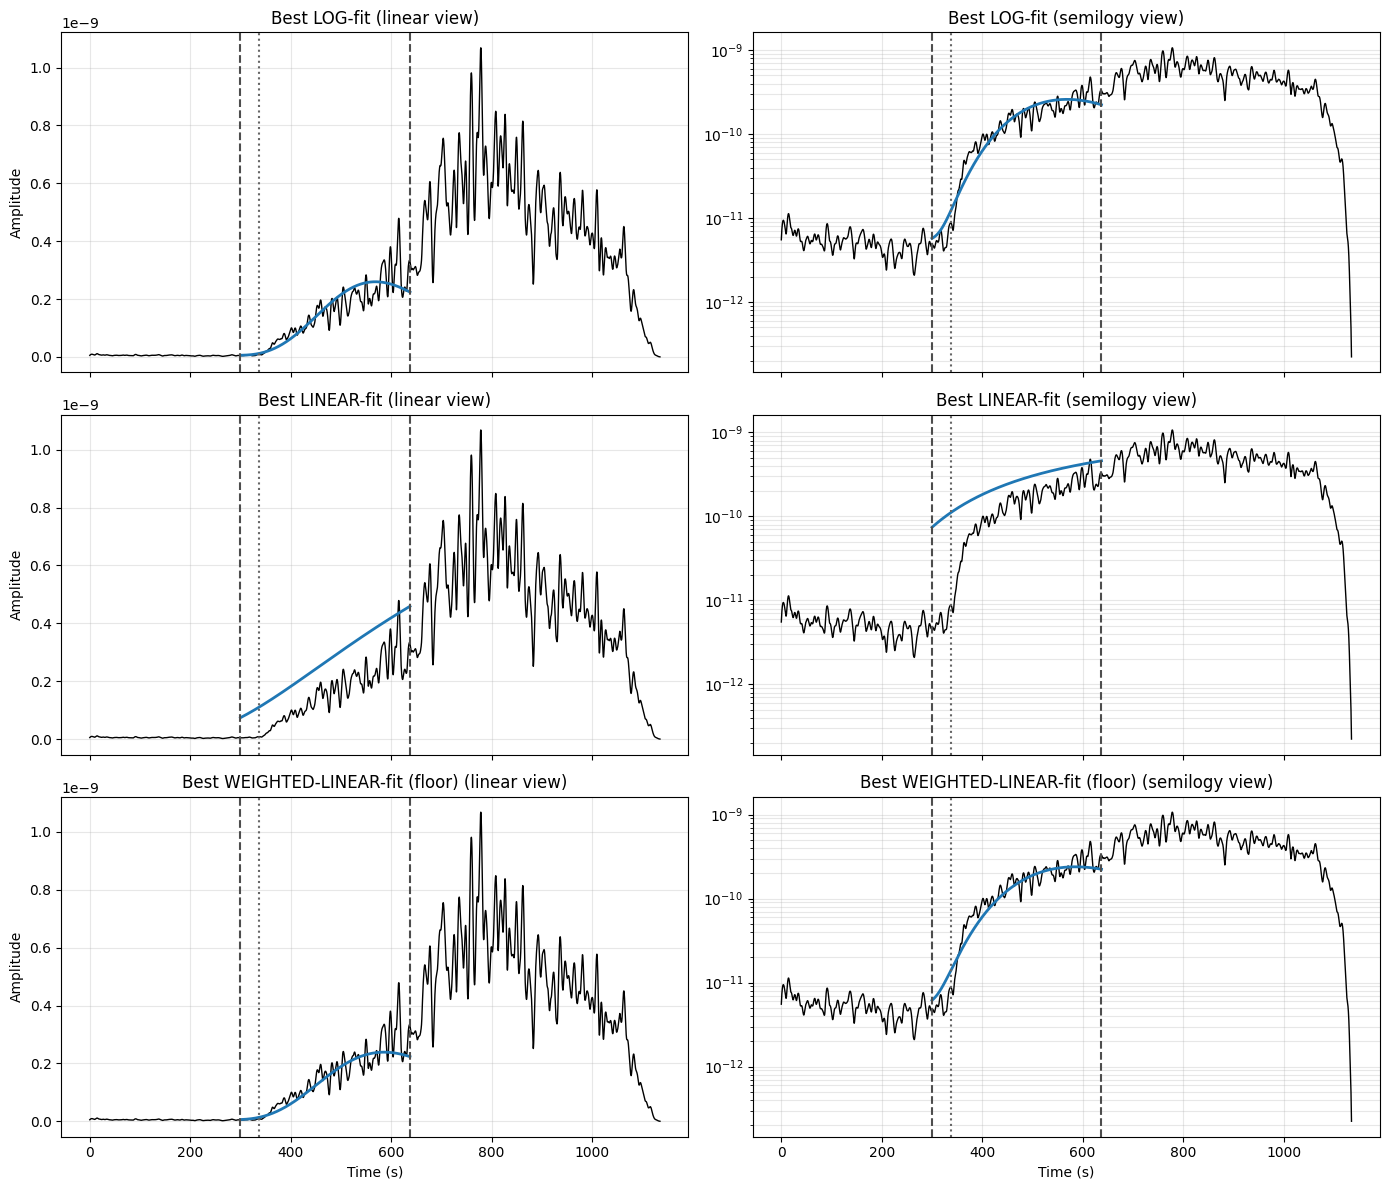


=== BEST LOG ===
safe_start     : 300.000 s
fit_window     : 300.000 → 637.498 s
t0excel_s      : 337.498 s
end_after_t0   : 300.000 s
weight_mode    : floor
sigma_floor_mult: 3.000

Parameters:
A               = 1.582836e+01
q               = 0.765931
a               = 1.459110e-01
s               = 68.974481
n0 (noise floor)= 5.346695e-12

sse_log       = 1.622236e+03

=== BEST LINEAR ===
safe_start     : 300.000 s
fit_window     : 300.000 → 637.498 s
t0excel_s      : 337.498 s
end_after_t0   : 300.000 s
weight_mode    : floor
sigma_floor_mult: 3.000

Parameters:
A               = 6.949085e-09
q               = 0.980000
a               = 6.345059e-03
s               = 755.286835
n0 (noise floor)= 5.346695e-12

sse_lin       = 2.719424e-16

=== BEST WEIGHTED LINEAR ===
safe_start     : 300.000 s
fit_window     : 300.000 → 637.498 s
t0excel_s      : 337.498 s
end_after_t0   : 300.000 s
weight_mode    : floor
sigma_floor_mult: 3.000

Parameters:
A               = 1.554236e-01
q        

In [331]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------------------------------------------------------
# EXPECTED TO EXIST IN YOUR NOTEBOOK:
#   - _diffusion_log_e(tt, A, q, a, s, D): returns log(amp_diff^2)
#   - diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0): returns amp_total
# -------------------------------------------------------------------

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """Return log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    return 0.5 * np.logaddexp(log_e, log_n0sq)


def best_safe_start_compare_log_linear_weighted(
    t, amp, *, D,
    t0excel_s,
    end_after_t0=200.0,
    safe_start_grid=np.arange(100.0, 301.0, 10.0),
    maxfev=200000,
    plot=True,
    # ---- weighting controls for weighted linear fit
    weight_mode="prop",     # "prop" => sigma ~ amp (relative error); "floor" => sigma ~ sqrt(amp^2 + n0^2)
    sigma_floor_mult=1.0,   # sigma minimum = sigma_floor_mult * n0 (prevents crazy weights near the floor)
    sigma_eps=1e-30,        # absolute epsilon clamp
):
    """
    Runs 3 fits per safe_start:
      - LOG-space fit: minimize ||log(amp) - log(model)||^2
      - LINEAR (unweighted): minimize ||amp - model||^2
      - LINEAR (weighted): minimize ||(amp - model)/sigma||^2, with sigma chosen by weight_mode

    Notes:
      - SSE values are not directly comparable across spaces. Compare shape + params.
      - Weighted linear SSE returned is SSE_w = sum(((y - yhat)/sigma)^2).
    """
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    t0excel_s = float(t0excel_s)
    fit_end_abs = t0excel_s + float(end_after_t0)

    bounds = (
        (1e-30, 1e-12, 1e-12, 1e-3),
        (1e+03, 1.0,   10.0,  1e6),
    )

    scan = []
    best_log = None
    best_lin = None
    best_wlin = None

    for ss in safe_start_grid:
        ss = float(ss)
        if ss >= fit_end_abs:
            continue

        # ---- noise floor estimate from [0, ss)
        noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
        if not np.any(noise_mask):
            continue
        n0 = float(np.mean(amp[noise_mask]))
        n0 = max(n0, 1e-30)

        # ---- fit window [ss, t0 + end_after_t0]
        fit_mask = (t >= ss) & (t <= fit_end_abs) & np.isfinite(amp) & (amp > 0)
        t_fit = t[fit_mask]
        amp_fit = amp[fit_mask]
        if t_fit.size < 20:
            continue

        # ---- initial guess
        A0 = float(np.median(amp_fit))
        q0 = 0.98
        a0 = 5e-3
        s0 = max(D / 4.0, 1e-2)
        p0 = (A0, q0, a0, s0)

        # Common model in linear amplitude domain
        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0)

        # -----------------------
        # LOG-SPACE FIT
        # -----------------------
        y_log = np.log(amp_fit)

        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

        popt_log = pcov_log = None
        sse_log = np.inf
        try:
            popt_log, pcov_log = curve_fit(
                f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev
            )
            ylog_pred = f_log(t_fit, *popt_log)
            sse_log = float(np.sum((y_log - ylog_pred) ** 2))
        except Exception:
            pass

        # -----------------------
        # LINEAR-SPACE FIT (UNWEIGHTED)
        # -----------------------
        y_lin = amp_fit
        popt_lin = pcov_lin = None
        sse_lin = np.inf
        try:
            popt_lin, pcov_lin = curve_fit(
                f_lin, t_fit, y_lin, p0=p0, bounds=bounds, maxfev=maxfev
            )
            ylin_pred = f_lin(t_fit, *popt_lin)
            sse_lin = float(np.sum((y_lin - ylin_pred) ** 2))
        except Exception:
            pass

        # -----------------------
        # LINEAR-SPACE FIT (WEIGHTED)
        # -----------------------
        # Build sigma (pointwise standard deviation model).
        # "prop": sigma ~ amp (relative-error model, like log-fit)
        # "floor": sigma ~ sqrt(amp^2 + n0^2) (keeps weights sane near floor)
        if weight_mode == "prop":
            sigma = np.maximum(amp_fit, sigma_floor_mult * n0)
        elif weight_mode == "floor":
            sigma = np.sqrt(np.maximum(amp_fit, 0.0)**2 + (sigma_floor_mult * n0)**2)
        else:
            raise ValueError("weight_mode must be 'prop' or 'floor'")

        sigma = np.maximum(sigma, sigma_eps)

        popt_wlin = pcov_wlin = None
        sse_wlin = np.inf
        try:
            popt_wlin, pcov_wlin = curve_fit(
                f_lin, t_fit, y_lin,
                p0=p0, bounds=bounds, maxfev=maxfev,
                sigma=sigma, absolute_sigma=False
            )
            y_wpred = f_lin(t_fit, *popt_wlin)
            sse_wlin = float(np.sum(((y_lin - y_wpred) / sigma) ** 2))
        except Exception:
            pass

        if (not np.isfinite(sse_log)) and (not np.isfinite(sse_lin)) and (not np.isfinite(sse_wlin)):
            continue

        row = dict(
            safe_start=ss,
            n0=n0,
            fit_start=ss,
            fit_end=fit_end_abs,
            t0excel_s=t0excel_s,
            end_after_t0=float(end_after_t0),

            popt_log=popt_log, pcov_log=pcov_log, sse_log=sse_log,
            popt_lin=popt_lin, pcov_lin=pcov_lin, sse_lin=sse_lin,
            popt_wlin=popt_wlin, pcov_wlin=pcov_wlin, sse_wlin=sse_wlin,

            weight_mode=weight_mode,
            sigma_floor_mult=float(sigma_floor_mult),
        )
        scan.append(row)

        if np.isfinite(sse_log) and ((best_log is None) or (sse_log < best_log["sse_log"])):
            best_log = row
        if np.isfinite(sse_lin) and ((best_lin is None) or (sse_lin < best_lin["sse_lin"])):
            best_lin = row
        if np.isfinite(sse_wlin) and ((best_wlin is None) or (sse_wlin < best_wlin["sse_wlin"])):
            best_wlin = row

    if not scan:
        raise RuntimeError("No successful fits in scan.")

    # -----------------------
    # PLOTTING
    # -----------------------
    if plot:
        ss_vals = [r["safe_start"] for r in scan]
        sse_log_vals  = [r["sse_log"]  for r in scan]
        sse_lin_vals  = [r["sse_lin"]  for r in scan]
        sse_wlin_vals = [r["sse_wlin"] for r in scan]

        plt.figure(figsize=(10, 4))
        plt.plot(ss_vals, sse_log_vals,  marker="o", label="Log-space SSE")
        plt.plot(ss_vals, sse_lin_vals,  marker="o", label="Linear SSE")
        plt.plot(ss_vals, sse_wlin_vals, marker="o", label=f"Weighted linear SSE (mode={weight_mode})")

        if best_log is not None:
            plt.axvline(best_log["safe_start"],  color="r", ls="--", alpha=0.6,
                        label=f"Best log ss={best_log['safe_start']:.1f}s")
        if best_lin is not None:
            plt.axvline(best_lin["safe_start"],  color="b", ls="--", alpha=0.6,
                        label=f"Best lin ss={best_lin['safe_start']:.1f}s")
        if best_wlin is not None:
            plt.axvline(best_wlin["safe_start"], color="g", ls="--", alpha=0.6,
                        label=f"Best wlin ss={best_wlin['safe_start']:.1f}s")

        plt.axvline(t0excel_s, color="0.4", ls=":", label="t0excel")
        plt.xlabel("safe_start (s)")
        plt.ylabel("SSE (different definitions!)")
        plt.title("Compare log vs linear vs weighted-linear across safe_start")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ---- best-fit overlays (3 rows: log / lin / wlin) x (linear view, semilogy)
        fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

        def plot_best(row, popt_key, r, title):
            if row is None or row[popt_key] is None:
                axes[r, 0].set_title(title + " (no fit)")
                axes[r, 1].set_title(title + " (no fit)")
                return

            A, q, a, s = row[popt_key]
            n0 = row["n0"]
            t_model = np.linspace(row["fit_start"], row["fit_end"], 1200)
            amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, n0)

            # linear
            axes[r, 0].plot(t, amp, lw=1, color="k")
            axes[r, 0].plot(t_model, amp_model, lw=2)
            axes[r, 0].axvline(row["fit_start"], ls="--", color="0.3")
            axes[r, 0].axvline(row["fit_end"],   ls="--", color="0.3")
            axes[r, 0].axvline(t0excel_s,        ls=":",  color="0.4")
            axes[r, 0].set_title(title + " (linear view)")
            axes[r, 0].grid(True, alpha=0.3)

            # semilogy
            axes[r, 1].semilogy(t, amp, lw=1, color="k")
            axes[r, 1].semilogy(t_model, amp_model, lw=2)
            axes[r, 1].axvline(row["fit_start"], ls="--", color="0.3")
            axes[r, 1].axvline(row["fit_end"],   ls="--", color="0.3")
            axes[r, 1].axvline(t0excel_s,        ls=":",  color="0.4")
            axes[r, 1].set_title(title + " (semilogy view)")
            axes[r, 1].grid(True, which="both", alpha=0.3)

        plot_best(best_log,  "popt_log",  0, "Best LOG-fit")
        plot_best(best_lin,  "popt_lin",  1, "Best LINEAR-fit")
        plot_best(best_wlin, "popt_wlin", 2, f"Best WEIGHTED-LINEAR-fit ({weight_mode})")

        for rr in range(3):
            axes[rr, 0].set_ylabel("Amplitude")
        axes[2, 0].set_xlabel("Time (s)")
        axes[2, 1].set_xlabel("Time (s)")
        plt.tight_layout()
        plt.show()

    return best_log, best_lin, best_wlin, scan


def print_best(label, best, popt_key, sse_key):
    if best is None or best.get(popt_key) is None:
        print(f"\n=== BEST {label} ===")
        print("No successful fit.")
        return

    A, q, a, s = best[popt_key]
    n0 = best["n0"]

    print(f"\n=== BEST {label} ===")
    print(f"safe_start     : {best['safe_start']:.3f} s")
    print(f"fit_window     : {best['fit_start']:.3f} → {best['fit_end']:.3f} s")
    print(f"t0excel_s      : {best['t0excel_s']:.3f} s")
    print(f"end_after_t0   : {best['end_after_t0']:.3f} s")
    if "weight_mode" in best:
        print(f"weight_mode    : {best['weight_mode']}")
        print(f"sigma_floor_mult: {best['sigma_floor_mult']:.3f}")
    print("")
    print("Parameters:")
    print(f"A               = {A:.6e}")
    print(f"q               = {q:.6f}")
    print(f"a               = {a:.6e}")
    print(f"s               = {s:.6f}")
    print(f"n0 (noise floor)= {n0:.6e}")
    print("")
    print(f"{sse_key}       = {best[sse_key]:.6e}")


# -------------------------
# Example usage (matches your style)
# -------------------------
after_t0 = 300
best_log, best_lin, best_wlin, scan = best_safe_start_compare_log_linear_weighted(
    t, rms,
    D=D_km,
    t0excel_s=t0_line_band,
    end_after_t0=after_t0,
    safe_start_grid=np.arange(10, t0_line_band - 30, 10),
    plot=True,
    weight_mode="floor",       # try "prop" and "floor"
    sigma_floor_mult=3.0,
)

print_best("LOG",            best_log,  "popt_log",  "sse_log")
print_best("LINEAR",         best_lin,  "popt_lin",  "sse_lin")
print_best("WEIGHTED LINEAR", best_wlin, "popt_wlin", "sse_wlin")

Trace start: 1974-07-11T00:37:00.006245Z
D_km: 3021.137307170133
Number of bands: 7


,event,band,fl_Hz,fu_Hz,t0_excel_utc,t0_line_s,D_km,safe_start_log,fit_end_log,n0_log,...,safe_start_wlin,fit_end_wlin,n0_wlin,A_wlin,q_wlin,a_wlin,s_wlin,sse_wlin,weight_mode,sigma_floor_mult
0,1974-07-11 00:37:00.006000+00:00__S14,3.0,2.5,3.5,1974-07-11 00:52:04.720000+00:00,904.713755,3021.137307,840.0,1204.713755,1.423879e-11,...,810.0,1204.713755,1.448862e-11,556.089821,2.569037e-07,0.001151,443.605487,3747.084088,floor,3.0
1,1974-07-11 00:37:00.006000+00:00__S14,4.0,3.5,4.5,1974-07-11 00:52:09.374000+00:00,909.367755,3021.137307,870.0,1209.367755,1.190058e-11,...,860.0,1209.367755,1.199131e-11,58.219341,1.908491e-07,0.001001,486.509668,3280.214903,floor,3.0
2,1974-07-11 00:37:00.006000+00:00__S14,5.0,4.5,5.5,1974-07-11 00:52:15.850000+00:00,915.843755,3021.137307,880.0,1215.843755,1.004026e-11,...,850.0,1215.843755,1.019902e-11,71.497672,2.547418e-07,0.001007,476.941313,2713.052411,floor,3.0
3,1974-07-11 00:37:00.006000+00:00__S14,6.0,5.5,6.5,1974-07-11 00:52:21.222000+00:00,921.215755,3021.137307,880.0,1221.215755,8.879415e-12,...,890.0,1221.215755,8.851278e-12,79.269064,2.084723e-07,0.001013,474.180245,2088.514014,floor,3.0
4,1974-07-11 00:37:00.006000+00:00__S14,7.0,6.5,7.5,1974-07-11 00:52:28.507000+00:00,928.500755,3021.137307,880.0,1228.500755,7.498043e-12,...,820.0,1228.500755,7.770785e-12,68.329555,2.353035e-07,0.000957,480.395121,2176.086081,floor,3.0
5,1974-07-11 00:37:00.006000+00:00__S14,8.0,7.5,8.5,1974-07-11 00:52:35.552000+00:00,935.545755,3021.137307,900.0,1235.545755,6.443270e-12,...,900.0,1235.545755,6.443270e-12,74.616790,2.223260e-07,0.000985,473.316229,2128.853002,floor,3.0
6,1974-07-11 00:37:00.006000+00:00__S14,9.0,8.5,9.5,1974-07-11 00:52:42.221000+00:00,942.214755,3021.137307,880.0,1242.214755,6.329410e-12,...,900.0,1242.214755,6.310418e-12,80.312155,1.875652e-07,0.000957,477.897289,2274.128637,floor,3.0


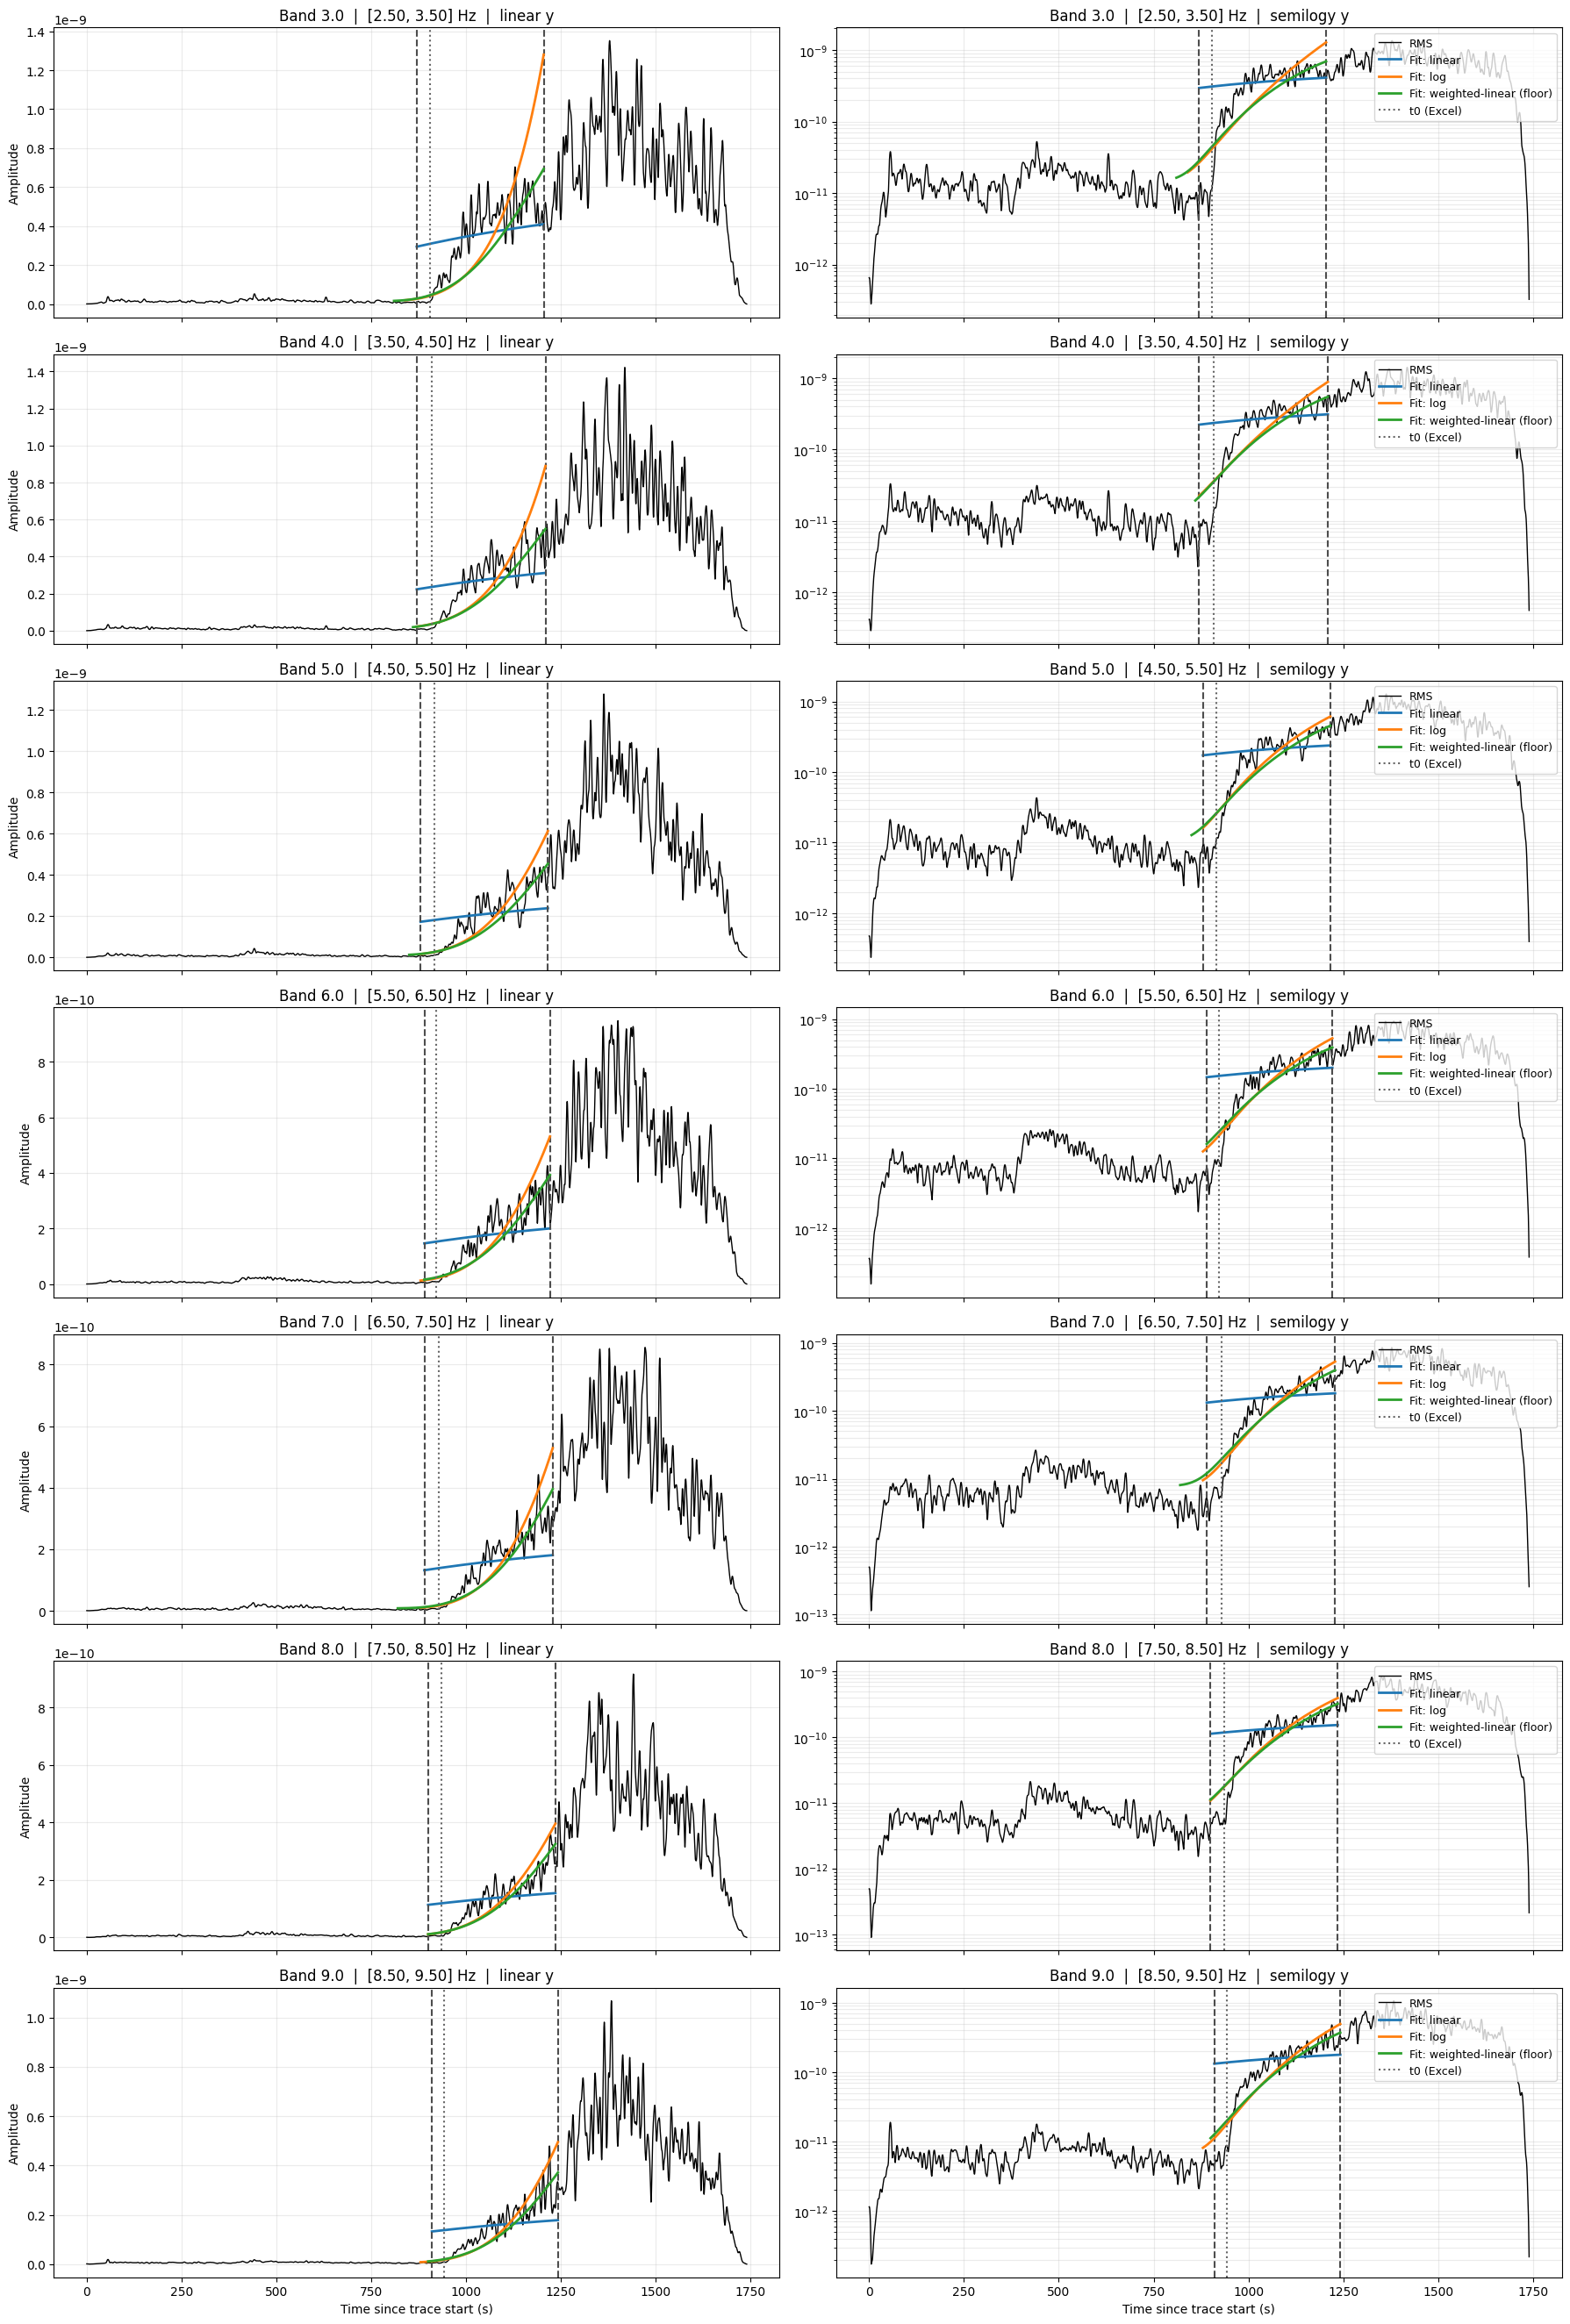

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from scipy.optimize import curve_fit

# -------------------------------------------------------------------
# EXPECTED TO EXIST IN YOUR NOTEBOOK / PIPELINE:
#   - tr_chosen                 (ObsPy Trace for chosen_event)
#   - chosen_event              (index key into t0_mat)
#   - chosen_row                (row-like with epi_deg)
#   - t0_mat                    (DataFrame indexed by event; columns are band labels)
#   - BANDS                     (list of band labels EXACTLY matching Excel columns)
#   - band_edges(fc_band, half_bw, fs) -> (fl, fu)
#   - env_and_rms(x, fs, fl, fu, win_s, order) -> (env, rms)
#   - _diffusion_log_e(tt, A, q, a, s, D)
#   - diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0)
# -------------------------------------------------------------------

# ============================================================
# 0) Diffusion helpers
# ============================================================
def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """Return log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)  # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                 # log(n0^2)
    return 0.5 * np.logaddexp(log_e, log_n0sq)


def best_safe_start_compare_log_linear_weighted(
    t, amp, *, D,
    t0excel_s,
    end_after_t0=200.0,
    safe_start_grid=np.arange(100.0, 301.0, 10.0),
    maxfev=200000,
    plot=False,              # keep False in the band loop (we'll do combined plots)
    weight_mode="floor",     # "prop" or "floor"
    sigma_floor_mult=3.0,
    sigma_eps=1e-30,
):
    """
    Returns: best_log, best_lin, best_wlin, scan
    Each 'best_*' row includes:
        - safe_start, n0, fit_start, fit_end, t0excel_s, end_after_t0
        - popt_* and sse_* entries
    """
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    t0excel_s = float(t0excel_s)
    fit_end_abs = t0excel_s + float(end_after_t0)

    bounds = (
        (1e-30, 1e-12, 1e-12, 1e-3),
        (1e+03, 1.0,   10.0,  1e6),
    )

    scan = []
    best_log = None
    best_lin = None
    best_wlin = None

    for ss in safe_start_grid:
        ss = float(ss)
        if ss >= fit_end_abs:
            continue

        # ---- noise floor estimate from [0, ss)
        noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
        if not np.any(noise_mask):
            continue
        n0 = float(np.mean(amp[noise_mask]))
        n0 = max(n0, 1e-30)

        # ---- fit window [ss, t0 + end_after_t0]
        fit_mask = (t >= ss) & (t <= fit_end_abs) & np.isfinite(amp) & (amp > 0)
        t_fit = t[fit_mask]
        amp_fit = amp[fit_mask]
        if t_fit.size < 20:
            continue

        # ---- initial guess
        A0 = float(np.median(amp_fit))
        q0 = 0.98
        a0 = 5e-3
        s0 = max(D / 4.0, 1e-2)
        p0 = (A0, q0, a0, s0)

        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0)

        # -----------------------
        # LOG-SPACE FIT
        # -----------------------
        y_log = np.log(amp_fit)

        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

        popt_log = pcov_log = None
        sse_log = np.inf
        try:
            popt_log, pcov_log = curve_fit(
                f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev
            )
            ylog_pred = f_log(t_fit, *popt_log)
            sse_log = float(np.sum((y_log - ylog_pred) ** 2))
        except Exception:
            pass

        # -----------------------
        # LINEAR-SPACE FIT (UNWEIGHTED)
        # -----------------------
        y_lin = amp_fit
        popt_lin = pcov_lin = None
        sse_lin = np.inf
        try:
            popt_lin, pcov_lin = curve_fit(
                f_lin, t_fit, y_lin, p0=p0, bounds=bounds, maxfev=maxfev
            )
            ylin_pred = f_lin(t_fit, *popt_lin)
            sse_lin = float(np.sum((y_lin - ylin_pred) ** 2))
        except Exception:
            pass

        # -----------------------
        # LINEAR-SPACE FIT (WEIGHTED)
        # -----------------------
        if weight_mode == "prop":
            sigma = np.maximum(amp_fit, sigma_floor_mult * n0)
        elif weight_mode == "floor":
            sigma = np.sqrt(np.maximum(amp_fit, 0.0) ** 2 + (sigma_floor_mult * n0) ** 2)
        else:
            raise ValueError("weight_mode must be 'prop' or 'floor'")
        sigma = np.maximum(sigma, sigma_eps)

        popt_wlin = pcov_wlin = None
        sse_wlin = np.inf
        try:
            popt_wlin, pcov_wlin = curve_fit(
                f_lin, t_fit, y_lin,
                p0=p0, bounds=bounds, maxfev=maxfev,
                sigma=sigma, absolute_sigma=False
            )
            y_wpred = f_lin(t_fit, *popt_wlin)
            sse_wlin = float(np.sum(((y_lin - y_wpred) / sigma) ** 2))
        except Exception:
            pass

        if (not np.isfinite(sse_log)) and (not np.isfinite(sse_lin)) and (not np.isfinite(sse_wlin)):
            continue

        row = dict(
            safe_start=ss,
            n0=n0,
            fit_start=ss,
            fit_end=fit_end_abs,
            t0excel_s=t0excel_s,
            end_after_t0=float(end_after_t0),

            popt_log=popt_log, pcov_log=pcov_log, sse_log=sse_log,
            popt_lin=popt_lin, pcov_lin=pcov_lin, sse_lin=sse_lin,
            popt_wlin=popt_wlin, pcov_wlin=pcov_wlin, sse_wlin=sse_wlin,

            weight_mode=weight_mode,
            sigma_floor_mult=float(sigma_floor_mult),
        )
        scan.append(row)

        if np.isfinite(sse_log) and ((best_log is None) or (sse_log < best_log["sse_log"])):
            best_log = row
        if np.isfinite(sse_lin) and ((best_lin is None) or (sse_lin < best_lin["sse_lin"])):
            best_lin = row
        if np.isfinite(sse_wlin) and ((best_wlin is None) or (sse_wlin < best_wlin["sse_wlin"])):
            best_wlin = row

    if not scan:
        raise RuntimeError("No successful fits in scan.")

    # (We intentionally do NOT plot here; we plot combined per-band later.)
    return best_log, best_lin, best_wlin, scan


# ============================================================
# 1) Full-trace setup (NO TRIMMING)
# ============================================================
t0_row = t0_mat.loc[chosen_event]  # Series indexed by Excel band labels

tr_full = tr_chosen.copy()
fs = tr_full.stats.sampling_rate
t = tr_full.times()  # seconds since tr_full.stats.starttime

# Distance rule (your rule)
D_km = float(chosen_row["epi_deg"]) * 30.0

# Use same bands as Excel
frequency_bands = list(BANDS)

# Filter/Envelope params (your snippet)
half_bw = 0.5
win_s   = 10
order   = 4

print("Trace start:", tr_full.stats.starttime)
print("D_km:", D_km)
print("Number of bands:", len(frequency_bands))

# ============================================================
# 2) Loop bands: env/RMS + fits (log + lin + weighted-lin) + store
# ============================================================
after_t0 = 300.0
weight_mode = "floor"
sigma_floor_mult = 3.0

band_store = {}   # keyed by band: holds rms + t0 + best fits
rows = []         # summary table

for fc_band in frequency_bands:
    # --- band-specific Excel t0 ---
    t0_utc_band = t0_row.get(fc_band, pd.NaT)
    if pd.isna(t0_utc_band):
        print(f"Skipping band {fc_band}: no t0 in Excel for event {chosen_event}")
        continue

    t0_obspy_band = UTCDateTime(pd.Timestamp(t0_utc_band).to_pydatetime())
    t0_line_band = float(t0_obspy_band - tr_full.stats.starttime)  # seconds since trace start
    if not np.isfinite(t0_line_band) or t0_line_band <= 0:
        print(f"Skipping band {fc_band}: invalid t0_line={t0_line_band}")
        continue

    # --- full-trace RMS for this band ---
    fl, fu = band_edges(fc_band, half_bw, fs)
    env_full, rms_full = env_and_rms(tr_full.data.astype(float), fs, fl, fu, win_s, order)

    # --- safe_start grid (same logic you used, relative to that band's t0) ---
    ss_max = max(t0_line_band - 30.0, 0.0)
    safe_grid = np.arange(10.0, ss_max, 10.0)
    if safe_grid.size == 0:
        print(f"Skipping band {fc_band}: safe_start grid empty (t0={t0_line_band:.1f}s)")
        continue

    # --- fits (NO per-band plotting here) ---
    try:
        best_log, best_lin, best_wlin, scan = best_safe_start_compare_log_linear_weighted(
            t, rms_full,
            D=D_km,
            t0excel_s=t0_line_band,
            end_after_t0=after_t0,
            safe_start_grid=safe_grid,
            plot=False,
            weight_mode=weight_mode,
            sigma_floor_mult=sigma_floor_mult,
        )
    except Exception as e:
        print(f"Fit failed for band {fc_band}: {e}")
        continue

    # Store for combined plot
    band_store[fc_band] = dict(
        fl=fl, fu=fu,
        t=t,
        rms=rms_full,
        t0_line=t0_line_band,
        best_log=best_log,
        best_lin=best_lin,
        best_wlin=best_wlin,
    )

    # Summarize in a row (parameters can differ by method, so store per-method)
    def _pack_params(best, key):
        if best is None or best.get(key) is None:
            return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)
        A, q, a, s = best[key]
        return (A, q, a, s, best["n0"], best["safe_start"], best["fit_end"])

    Alog, qlog, alog, slog, n0log, sslog, fe_log = _pack_params(best_log, "popt_log")
    Alin, qlin, alin, slin, n0lin, sslin, fe_lin = _pack_params(best_lin, "popt_lin")
    Awl,  qwl,  awl,  swl,  n0wl,  sswl,  fe_wl  = _pack_params(best_wlin, "popt_wlin")

    rows.append(dict(
        event=chosen_event,
        band=fc_band,
        fl_Hz=fl, fu_Hz=fu,
        t0_excel_utc=pd.Timestamp(t0_utc_band),
        t0_line_s=t0_line_band,
        D_km=D_km,

        # best LOG
        safe_start_log=sslog, fit_end_log=fe_log, n0_log=n0log,
        A_log=Alog, q_log=qlog, a_log=alog, s_log=slog, sse_log=float(best_log["sse_log"]) if best_log else np.nan,

        # best LIN
        safe_start_lin=sslin, fit_end_lin=fe_lin, n0_lin=n0lin,
        A_lin=Alin, q_lin=qlin, a_lin=alin, s_lin=slin, sse_lin=float(best_lin["sse_lin"]) if best_lin else np.nan,

        # best WEIGHTED LIN
        safe_start_wlin=sswl, fit_end_wlin=fe_wl, n0_wlin=n0wl,
        A_wlin=Awl, q_wlin=qwl, a_wlin=awl, s_wlin=swl, sse_wlin=float(best_wlin["sse_wlin"]) if best_wlin else np.nan,

        weight_mode=weight_mode,
        sigma_floor_mult=sigma_floor_mult,
    ))

results_df = pd.DataFrame(rows).sort_values(["band"])
display(results_df)

# ============================================================
# 3) Combined plot: per-band rows, 2 columns (linear + semilogy),
#    each subplot shows RMS + 3 fits (log, linear, weighted-linear)
# ============================================================
if not band_store:
    raise RuntimeError("No bands produced results. Check Excel t0s/BANDS labels and fit settings.")

bands_ok = list(band_store.keys())
n = len(bands_ok)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(18, 3.8 * n),
    sharex=True
)

if n == 1:
    axes = np.array([axes])  # shape (1, 2)

def _model_from_best(best, method_key, D_km):
    """
    Build (t_model, amp_model, safe_start, fit_end, n0) from a best row, or return None.
    method_key: 'popt_log' or 'popt_lin' or 'popt_wlin'
    """
    if best is None:
        return None
    popt = best.get(method_key)
    if popt is None:
        return None
    A, q, a, s = popt
    n0 = float(best["n0"])
    fit_start = float(best["fit_start"])
    fit_end = float(best["fit_end"])
    t_model = np.linspace(fit_start, fit_end, 1200)
    amp_model = diffusion_amp_floor(t_model, A, q, a, s, D_km, n0)
    return t_model, amp_model, fit_start, fit_end, n0

for i, b in enumerate(bands_ok):
    d = band_store[b]
    tt = d["t"]
    rms = d["rms"]
    t0s = float(d["t0_line"])
    fl, fu = d["fl"], d["fu"]

    # build the 3 model curves
    m_log  = _model_from_best(d["best_log"],  "popt_log",  D_km)
    m_lin  = _model_from_best(d["best_lin"],  "popt_lin",  D_km)
    m_wlin = _model_from_best(d["best_wlin"], "popt_wlin", D_km)

    axL = axes[i, 0]
    axS = axes[i, 1]

    # --- data
    axL.plot(tt, rms, lw=1.0, color="k", label="RMS")
    axS.semilogy(tt, rms, lw=1.0, color="k", label="RMS")

    # --- fits (same curves drawn on both axes)
    if m_lin is not None:
        t_m, y_m, ss, fe, _ = m_lin
        axL.plot(t_m, y_m, lw=2.0, label="Fit: linear")
        axS.semilogy(t_m, y_m, lw=2.0, label="Fit: linear")
        axL.axvline(ss, ls="--", color="0.3")
        axL.axvline(fe, ls="--", color="0.3")
        axS.axvline(ss, ls="--", color="0.3")
        axS.axvline(fe, ls="--", color="0.3")

    if m_log is not None:
        t_m, y_m, ss, fe, _ = m_log
        axL.plot(t_m, y_m, lw=2.0, label="Fit: log")
        axS.semilogy(t_m, y_m, lw=2.0, label="Fit: log")

    if m_wlin is not None:
        t_m, y_m, ss, fe, _ = m_wlin
        axL.plot(t_m, y_m, lw=2.0, label=f"Fit: weighted-linear ({weight_mode})")
        axS.semilogy(t_m, y_m, lw=2.0, label=f"Fit: weighted-linear ({weight_mode})")

    # --- t0 line
    axL.axvline(t0s, ls=":", color="0.4", label="t0 (Excel)")
    axS.axvline(t0s, ls=":", color="0.4", label="t0 (Excel)")

    # Titles / cosmetics
    axL.set_title(f"Band {b}  |  [{fl:.2f}, {fu:.2f}] Hz  |  linear y")
    axS.set_title(f"Band {b}  |  [{fl:.2f}, {fu:.2f}] Hz  |  semilogy y")

    axL.set_ylabel("Amplitude")
    axL.grid(True, alpha=0.25)
    axS.grid(True, which="both", alpha=0.25)

    # Keep legends readable: only on right column, per row
    axS.legend(loc="upper right", fontsize=9)

axes[-1, 0].set_xlabel("Time since trace start (s)")
axes[-1, 1].set_xlabel("Time since trace start (s)")
plt.tight_layout()
plt.show()